# Setup

In [1]:

!pip install -q langgraph langchain openai langsmith graphviz

In [2]:
!pip install -q langchain_community

In [3]:
import os
from langchain.chat_models import ChatOpenAI
from langchain.tools import tool
from langgraph.graph import StateGraph, END
from langsmith import traceable
import graphviz

# Set up LangSmith (REQUIRED for tracing)

In [4]:

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "react-pattern-langgraph"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""  # Replace this securely

In [5]:
# Optional: Set OpenAI or Groq API key
os.environ["OPENAI_API_KEY"] = "sk---"


# Define Tools

In [6]:
# ---
# Define Tools
@tool
def search_web(query: str) -> str:
    """Use the web to look something up."""
    return f"[FAKE SEARCH RESULT for '{query}']"

@tool
def calculator(expression: str) -> str:
    """Do basic math operations."""
    try:
        return str(eval(expression))
    except:
        return "Error in calculation."

# Rename tools to ensure name mapping
search_web.name = "search_web"
calculator.name = "calculator"
tools = [search_web, calculator]

# Custom ToolInvocation and ToolExecutor fallback
class ToolInvocation:
    def __init__(self, tool: str, tool_input: str):
        self.tool = tool
        self.tool_input = tool_input

class SimpleToolExecutor:
    def __init__(self, tools):
        self.tool_map = {tool.name: tool for tool in tools}

    def invoke(self, invocation):
        tool_fn = self.tool_map[invocation.tool]
        return tool_fn.invoke(invocation.tool_input)

tool_executor = SimpleToolExecutor(tools)

# Define ReAct Agent

In [12]:
# ---
#  Define ReAct Agent
@traceable(name="ReActAgent")
def react_agent(state):
    history = state.get("history", [])
    inputs = state["input"]

    llm = ChatOpenAI(temperature=0)
# ---
#  Define ReAct Agent
@traceable(name="ReActAgent")
def react_agent(state):
    history = state.get("history", [])
    inputs = state["input"]

    llm = ChatOpenAI(temperature=0)

    SYSTEM_PROMPT = (
        "You are a smart assistant. Think step-by-step.\n"
        "Use ReAct format where necessary.\n"
        "If needed, say Action: search_web[<query>]\n"
        "Or say Action: calculator[<expression>]\n"
        "Otherwise, respond directly."
    )

    messages = [{"role": "system", "content": SYSTEM_PROMPT}] + history + [{"role": "user", "content": inputs}]
    response = llm.invoke(messages)

    content = response.content

    if content.startswith("Action: "):
        action_line = content[len("Action: "):]
        name, arg = action_line.split("[")[0], action_line.split("[")[1].rstrip("]")
        return {"tool_invocation": ToolInvocation(tool=name.strip(), tool_input=arg.strip()), "history": messages + [response]}
# ---
#  Define ReAct Agent
@traceable(name="ReActAgent")
def react_agent(state):
    history = state.get("history", [])
    inputs = state["input"]

    llm = ChatOpenAI(temperature=0)

    SYSTEM_PROMPT = (
        "You are a smart assistant. Think step-by-step.\n"
        "Use ReAct format where necessary.\n"
        "If needed, say Action: search_web[<query>]\n"
        "Or say Action: calculator[<expression>]\n"
        "Otherwise, respond directly."
    )

    messages = [{"role": "system", "content": SYSTEM_PROMPT}] + history + [{"role": "user", "content": inputs}]
    response = llm.invoke(messages)

    content = response.content

    if content.startswith("Action: "):
        action_line = content[len("Action: "):]
        name, arg = action_line.split("[")[0], action_line.split("[")[1].rstrip("]")
        return {"tool_invocation": ToolInvocation(tool=name.strip(), tool_input=arg.strip()), "history": messages + [response]}
# ---
#  Define ReAct Agent
@traceable(name="ReActAgent")
def react_agent(state):
    history = state.get("history", [])
    inputs = state["input"]

    llm = ChatOpenAI(temperature=0)

    SYSTEM_PROMPT = (
        "You are a smart assistant. Think step-by-step.\n"
        "Use ReAct format where necessary.\n"
        "If needed, say Action: search_web[<query>]\n"
        "Or say Action: calculator[<expression>]\n"
        "Otherwise, respond directly."
    )

    messages = [{"role": "system", "content": SYSTEM_PROMPT}] + history + [{"role": "user", "content": inputs}]
    response = llm.invoke(messages)

    content = response.content

    if content.startswith("Action: "):
        action_line = content[len("Action: "):]
        name, arg = action_line.split("[")[0], action_line.split("[")[1].rstrip("]")
        return {"tool_invocation": ToolInvocation(tool=name.strip(), tool_input=arg.strip()), "history": messages + [response]}
# ---
# Define ReAct Agent
@traceable(name="ReActAgent")
def react_agent(state):
    history = state.get("history", [])
    inputs = state["input"]

    llm = ChatOpenAI(temperature=0)

    SYSTEM_PROMPT = (
        "You are a smart assistant. Think step-by-step.\n"
        "Use ReAct format where necessary.\n"
        "If needed, say Action: search_web[<query>]\n"
        "Or say Action: calculator[<expression>]\n"
        "Otherwise, respond directly."
    )

    messages = [{"role": "system", "content": SYSTEM_PROMPT}] + history + [{"role": "user", "content": inputs}]
    response = llm.invoke(messages)

    content = response.content

    if content.startswith("Action: "):
        action_line = content[len("Action: "):]
        name, arg = action_line.split("[")[0], action_line.split("[")[1].rstrip("]")
        return {"tool_invocation": ToolInvocation(tool=name.strip(), tool_input=arg.strip()), "history": messages + [response]}
    else:
        return {"final_answer": content, "history": messages + [response]}
    response = llm.invoke(messages)

    content = response.content

    if content.startswith("Action: "):
        action_line = content[len("Action: "):]
        name, arg = action_line.split("[")[0], action_line.split("[")[1].rstrip("]")
        return {"tool_invocation": ToolInvocation(tool=name.strip(), tool_input=arg.strip()), "history": messages + [response]}
    else:
        return {"final_answer": content, "history": messages + [response]}

# Tool Execution Node

In [13]:
# ---
# Tool Execution Node
@traceable(name="ToolExec")
def run_tool(state):
    invocation = state["tool_invocation"]
    result = tool_executor.invoke(invocation)
    state["input"] = result
    state["history"].append({"role": "tool", "content": result})
    return state

In [14]:
from typing import Dict, Any
from langgraph.graph import StateGraph, END
from langsmith import traceable

In [15]:
!pip install --upgrade langgraph

#  Define ReAct Loop Graph

In [16]:
# ---
#  Define ReAct Loop Graph
from typing import Dict, Any
workflow = StateGraph(state_schema=Dict[str, Any])
workflow.add_node("agent", react_agent)
workflow.add_node("tool", run_tool)

workflow.set_entry_point("agent")
def condition_fn(state):
    return "final_answer" in state

workflow.add_conditional_edges(
    "agent",
    condition_fn,
    {
        True: END,
        False: "tool",
    },
)
workflow.add_edge("tool", "agent")

graph = workflow.compile()

# Visualize the ReAct Graph

In [17]:
# ---
# Visualize the ReAct Graph
# Simplified static graph rendering
from graphviz import Digraph

viz = Digraph()
viz.attr(rankdir="LR")
viz.node("agent", shape="box")
viz.node("tool", shape="box")
viz.node("END", shape="oval")

viz.edge("agent", "tool", label="not done")
viz.edge("agent", "END", label="done")
viz.edge("tool", "agent")

viz.render("react_langgraph_simple", format="png", cleanup=False, view=True)
# removed draw_mermaid_png due to compatibility issues

'react_langgraph_simple.png'

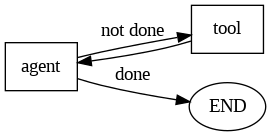

In [24]:
viz.render("react_langgraph_simple", format="png", cleanup=False, view=True)

from IPython.display import Image, display
display(Image(filename="react_langgraph_simple.png"))


# Run an Example

In [22]:
# ---
# Run an Example
inputs = {
    "input": "What's the capital of France and also what is 2+2?",
    "history": []
}
# ---
# Run an Example
inputs = {
    "input": "What's the capital of France and also what is 2+2?",
    "history": []
}

output = graph.invoke(inputs)
print("\n✅ Final Output:", output["final_answer"])


✅ Final Output: The capital of France is Paris. 

2 + 2 equals 4.


In [23]:
# ---
#  Suggested Prompt Format for Agent
print("""
Suggested prompt style for your ReAct agent:

You are a smart assistant. Think step-by-step.
- If needed, you may say Action: search_web[<query>]
- Or you may say Action: calculator[<expression>]
- Otherwise, respond directly.
""")


Suggested prompt style for your ReAct agent:

You are a smart assistant. Think step-by-step.
- If needed, you may say Action: search_web[<query>]
- Or you may say Action: calculator[<expression>]
- Otherwise, respond directly.

